In [139]:
# Use the same data preprocessing from Task 1

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

file_name = 'Asm1_dataset26.csv'
df = pd.read_csv(file_name)

# Cleaning the data
df.columns = df.columns.str.strip() # Column Hectares has a redundant space

# Remove duplicated rows
df = df.drop_duplicates(keep='first')

# Identify missing values
missing_value = df.isnull().sum()

# Impute missing values with its median
cols = ['Min temp_D1_D30', 'Min temp_D31_D60', 'Min temp_D61_D90', 'Min temp_D91_D120']
for col in cols:
    df[col] = df[col].fillna(df[col].median())

# Replace '--' with NA in categorical variables
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].replace('--', 'NA')

# Calculate the mean of the paddy yield per hectares
df['yield_per_hec'] = df['Paddy yield(in Kg)']/df['Hectares'] 
mean_yield = df['yield_per_hec'].mean()

# Create a column name 'isAboveAvg'
df['isAboveAvg'] = np.where(df['yield_per_hec'] > mean_yield, 1, 0)
df['isAboveAvg'].value_counts()

# Drop noisy columns
drop_cols = ['Hectares', 'Paddy yield(in Kg)', 'yield_per_hec', 'Trash(in bundles)']
df_clean = df.drop(columns = drop_cols)

# Correlation Analysis
## Encode categorical columns with One-hot encoding
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Separate input and target variables
X = df_encoded.drop(columns=['isAboveAvg'])
y = df_encoded['isAboveAvg']

corr_matrix = X.corr().abs()

# Find highly correlated pair-wise columns
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.98)]
df_final = X.drop(columns=high_corr_cols)

print(df_final.info())

<class 'pandas.DataFrame'>
Index: 2628 entries, 0 to 2788
Data columns (total 50 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Seedrate(in Kg)                     2628 non-null   int64  
 1   30DRain( in mm)                     2628 non-null   float64
 2   30_50DRain( in mm)                  2628 non-null   float64
 3   51_70DRain(in mm)                   2628 non-null   float64
 4   Min temp_D1_D30                     2628 non-null   float64
 5   Max temp_D1_D30                     2628 non-null   int64  
 6   Min temp_D31_D60                    2628 non-null   float64
 7   Max temp_D31_D60                    2628 non-null   int64  
 8   Max temp_D61_D90                    2628 non-null   float64
 9   Min temp_D91_D120                   2628 non-null   float64
 10  Max temp_D91_D120                   2628 non-null   float64
 11  Inst Wind Speed_D1_D30(in Knots)    2628 non-null   int64  

/var/folders/p7/wgz8z2r94nqgs81btq4zyn_80000gn/T/ipykernel_34517/2212743223.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [140]:
# Split the data (same as Task 1)
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(
    df_final.values, y, random_state=random_state
)
print("Size of training set:", len(X_train))
print("Size of testing set:", len(X_test))

Size of training set: 1971
Size of testing set: 657


In [141]:
# Continuous or numeric columns that need further processing
numeric_cols = df_final.select_dtypes(include=['int64', 'float64']).columns.tolist()
# print(numeric_cols)

print(df_final.info())

<class 'pandas.DataFrame'>
Index: 2628 entries, 0 to 2788
Data columns (total 50 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Seedrate(in Kg)                     2628 non-null   int64  
 1   30DRain( in mm)                     2628 non-null   float64
 2   30_50DRain( in mm)                  2628 non-null   float64
 3   51_70DRain(in mm)                   2628 non-null   float64
 4   Min temp_D1_D30                     2628 non-null   float64
 5   Max temp_D1_D30                     2628 non-null   int64  
 6   Min temp_D31_D60                    2628 non-null   float64
 7   Max temp_D31_D60                    2628 non-null   int64  
 8   Max temp_D61_D90                    2628 non-null   float64
 9   Min temp_D91_D120                   2628 non-null   float64
 10  Max temp_D91_D120                   2628 non-null   float64
 11  Inst Wind Speed_D1_D30(in Knots)    2628 non-null   int64  

## 3.1 Regression Model Selection and Variables Further Processing
### Question 3.1  
*Describe which regression model was selected for the classification problem and what additional processing was required on this dataset to be used in regression modelling. List the variables that need further processing and provide details of the processing.*

**Response:**  
Logistic Regression Model was selected. Standardization of the dataset is used by calling the `StandardScaller()` method, because logistic regression is very sensitive to large feature scales so as to ensure fair comparison between features. Also, it ensures the later optimization works properly. 

Continuous or numeric values need further processing for standardization, which include the following variables:
1. Seedrate(in Kg)
2. 30DRain( in mm)
3. 30_50DRain( in mm)
4. 51_70DRain(in mm)
5. Min temp_D1_D30
6. Max temp_D1_D30
7. Min temp_D31_D60
8. Max temp_D31_D60
9. Max temp_D61_D90
10. Min temp_D91_D120
11. Max temp_D91_D120
12. Inst Wind Speed_D1_D30(in Knots)
13. Inst Wind Speed_D31_D60(in Knots)
14. Inst Wind Speed_D61_D90(in Knots)
15. Inst Wind Speed_D91_D120(in Knots)
16. Relative Humidity_D1_D30
17. Relative Humidity_D31_D60
18. Relative Humidity_D61_D90
19. Relative Humidity_D91_D120


In [142]:
from sklearn.preprocessing import StandardScaler

# Just scale the numeric columns
numeric_col_names = df_final.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_col_indices = (slice(None), [df_final.columns.get_loc(c) for c in numeric_col_names])

scaler = StandardScaler()

print("*************************")
print("Before scaling")
print("*************************")
for i in range(5):
    col = X_train[:, i]
    col_name = numeric_col_names[i]
    print(f"{col_name}: min {min(col)}, max {max(col)}, mean {np.mean(col):.2f}, std dev {np.std(col):.2f}")

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_col_indices] = scaler.fit_transform(X_train[numeric_col_indices])
X_test_scaled[numeric_col_indices] = scaler.transform(X_test[numeric_col_indices])

print("\n*************************")
print("After scaling")
print("*************************")
for i in range(5):
    col = X_train_scaled[:, i]
    col_name = numeric_col_names[i]
    print(f"{col_name}: min {col.min():.2f}, max {col.max():.2f}, mean {np.mean(col):.2f}, std dev {np.std(col):.2f}")

*************************
Before scaling
*************************
Seedrate(in Kg): min 25, max 150, mean 92.85, std dev 36.60
30DRain( in mm): min 18.1, max 19.6, mean 18.72, std dev 0.64
30_50DRain( in mm): min 185.2, max 187.2, mean 186.00, std dev 0.85
51_70DRain(in mm): min 165.3, max 167.0, mean 166.14, std dev 0.68
Min temp_D1_D30: min 18.0, max 20.5, mean 19.34, std dev 0.85

*************************
After scaling
*************************
Seedrate(in Kg): min -1.85, max 1.56, mean -0.00, std dev 1.00
30DRain( in mm): min -0.97, max 1.38, mean 0.00, std dev 1.00
30_50DRain( in mm): min -0.94, max 1.41, mean 0.00, std dev 1.00
51_70DRain(in mm): min -1.24, max 1.26, mean 0.00, std dev 1.00
Min temp_D1_D30: min -1.58, max 1.36, mean -0.00, std dev 1.00


## 3.2 Regression Model Building and Tunning
*Build a regression model tuned with GridSearchCV*

In [143]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Test with only C parameter
# params = {"C": [pow(10, x) for x in range(-6, 4)]}

params = {
    'C': [pow(10, x) for x in range(-6, 4)],
    "l1_ratio": [0, 1],
    'solver': ['liblinear', 'saga']
}

lr = LogisticRegression(random_state=random_state, max_iter=5000)
cv = GridSearchCV(
    param_grid=params,
    estimator=lr,
    cv=10,
    n_jobs=-1,
)

cv.fit(X_train_scaled, y_train)

print(f"Train accuracy: {cv.score(X_train_scaled, y_train)*100:.2f}%")
print(f"Test accuracy: {cv.score(X_test_scaled, y_test)*100:.2f}%")

y_pred = cv.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

# Get the best model from grid search
best_lr_model = cv.best_estimator_
# print parameters of the best model
print(f"The optimal parameter is: {cv.best_params_}")

Train accuracy: 88.94%
Test accuracy: 90.72%
              precision    recall  f1-score   support

           0       1.00      0.81      0.90       322
           1       0.85      1.00      0.92       335

    accuracy                           0.91       657
   macro avg       0.92      0.91      0.91       657
weighted avg       0.92      0.91      0.91       657

The optimal parameter is: {'C': 0.01, 'l1_ratio': 1, 'solver': 'liblinear'}


### Question 3.2(a)  
*Name the Regression function used.*

**Response**  
The regression function being used is Logistic Regression.

### Question 3.2(b)  
*What are the optimal parameters for this regression model? Explain your choice of hyperparameters to search, and the chosen search range(s)?*

**Response**  
Optimal parameters: `{'C': 0.01, 'l1_ratio': 1, 'solver': 'liblinear'}` is being used.

`C` represents "Inverse of regularization strength", it controls regularization in logistic regression. Using grid search method, `C` was searched over a logarithmic scale (10^6 to 10^3) (10^-6 to 10^3) to explore a wide range of regularisation strengths, it suggested `0.01` is the optimal value.

For the hyperparameter `l1_ratio`, it dictates the penalty type. The best type determined by the Grid Search is 1, so it indicates `L1`, which forces some feature weight to 0, meaning there is feature selection.

For the hyperparameter `solver`, the best solver suggested by Grid Search is `liblinear`, it is an alternate solver used to train Logistic Regression, and it is particularly suitable for small data set and it supports `L1` type penalty.

We tried to only include `C` as the hyperparameter, but results shows that adding penalty type and solver for optimization algorithm makes the model more stable.

With only `C`, the metrics are as follows:
- Train accuracy: 86.76%
- Test Accuracy: 89.04%

With `C`, `l1_ratio` and `solver`, the metrics are as follows:
- Train Accuracy: 88.94%
- Test Accuracy: 90.72%

### Question 3.2(c)  
*Report the variables that are included in the regression model.*

**Response**  
50 independent variables were fed into the Logistic Regression model, including all dummy-encoded categorical variables and the scaled continous variables.  

1. Seedrate(in Kg)                     2628 non-null   int64  
2. 30DRain( in mm)                     2628 non-null   float64
3. 30_50DRain( in mm)                  2628 non-null   float64
4. 51_70DRain(in mm)                   2628 non-null   float64
5. Min temp_D1_D30                     2628 non-null   float64
6. Max temp_D1_D30                     2628 non-null   int64  
7. Min temp_D31_D60                    2628 non-null   float64
8. Max temp_D31_D60                    2628 non-null   int64  
9. Max temp_D61_D90                    2628 non-null   float64
10. Min temp_D91_D120                   2628 non-null   float64
11. Max temp_D91_D120                   2628 non-null   float64
12. Inst Wind Speed_D1_D30(in Knots)    2628 non-null   int64  
13. Inst Wind Speed_D31_D60(in Knots)   2628 non-null   int64  
14. Inst Wind Speed_D61_D90(in Knots)   2628 non-null   int64  
15. Inst Wind Speed_D91_D120(in Knots)  2628 non-null   int64  
16. Relative Humidity_D1_D30            2628 non-null   float64
17. Relative Humidity_D31_D60           2628 non-null   int64  
18. Relative Humidity_D61_D90           2628 non-null   int64  
19. Relative Humidity_D91_D120          2628 non-null   int64  
20. Agriblock_Cuddalore                 2628 non-null   bool   
21. Agriblock_Kallakurichi              2628 non-null   bool   
22. Agriblock_Kurinjipadi               2628 non-null   bool   
23. Agriblock_Panruti                   2628 non-null   bool   
24. Agriblock_Sankarapuram              2628 non-null   bool   
25. Variety_delux ponni                 2628 non-null   bool   
26. Variety_ponmani                     2628 non-null   bool   
27. Soil Types_clay                     2628 non-null   bool   
28. Nursery_wet                         2628 non-null   bool   
29. Wind Direction_D1_D30_ENE           2628 non-null   bool   
30. Wind Direction_D1_D30_NA            2628 non-null   bool   
31. Wind Direction_D1_D30_NW            2628 non-null   bool   
32. Wind Direction_D1_D30_SSE           2628 non-null   bool   
33. Wind Direction_D1_D30_SW            2628 non-null   bool   
34. Wind Direction_D1_D30_W             2628 non-null   bool   
35. Wind Direction_D31_D60_NA           2628 non-null   bool   
36. Wind Direction_D31_D60_NE           2628 non-null   bool   
37. Wind Direction_D31_D60_S            2628 non-null   bool   
38. Wind Direction_D31_D60_W            2628 non-null   bool   
39. Wind Direction_D31_D60_WNW          2628 non-null   bool   
40. Wind Direction_D61_D90_NE           2628 non-null   bool   
41. Wind Direction_D61_D90_NNE          2628 non-null   bool   
42. Wind Direction_D61_D90_NNW          2628 non-null   bool   
43. Wind Direction_D61_D90_SE           2628 non-null   bool   
44. Wind Direction_D61_D90_SW           2628 non-null   bool   
45. Wind Direction_D91_D120_NNW         2628 non-null   bool   
46. Wind Direction_D91_D120_NW          2628 non-null   bool   
47. Wind Direction_D91_D120_S           2628 non-null   bool   
48. Wind Direction_D91_D120_SSE         2628 non-null   bool   
49. Wind Direction_D91_D120_W           2628 non-null   bool   
50. Wind Direction_D91_D120_WSW         2628 non-null   bool

### Question 3.2(d)  
*Report the top-10 important variables (in order) in the model.*

In [144]:
coef = best_lr_model.coef_[0]
feature_names = df_final.columns[:X_train_scaled.shape[1]]

indices = np.argsort(np.absolute(coef))
indices = np.flip(indices, axis=0)

indices = indices[:10] 

for i in indices:
    print(feature_names[i], ':', coef[i])

Seedrate(in Kg) : 1.646204188808442
Inst Wind Speed_D31_D60(in Knots) : 0.0
Agriblock_Panruti : 0.0
Agriblock_Kurinjipadi : 0.0
Agriblock_Kallakurichi : 0.0
Agriblock_Cuddalore : 0.0
Relative Humidity_D91_D120 : 0.0
Relative Humidity_D61_D90 : 0.0
Relative Humidity_D31_D60 : 0.0
Relative Humidity_D1_D30 : 0.0


**Response**  
Using the `coef_` attribute, the model returns the coefficients (weights) associated with each feature. The top 10 most important variables are:
1. Seedrate(in Kg)
2. Inst Wind Speed_D31_D60(in Knots)
3. Agriblock_Panruti
4. Agriblock_Kurinjipadi
5. Agriblock_Kallakurichi
6. Agriblock_Cuddalore
7. Relative Humidity_D91_D120
8. Relative Humidity_D61_D90
9. Relative Humidity_D31_D60
10. Relative Humidity_D1_D30

### Question 3.2(e)
*What is the classification accuracy on training and test datasets?*

In [145]:

print(f"Train accuracy: {cv.score(X_train_scaled, y_train)*100:.2f}%")
print(f"Test accuracy: {cv.score(X_test_scaled, y_test)*100:.2f}%")

Train accuracy: 88.94%
Test accuracy: 90.72%


**Response:**  
The classification accuracy is 88.94% on the training set and 90.72% on the test set.

# 3.3 Building Reduced Model 
*Build another regression model on the reduced variables set. To minimise variables, either perform dimensionality reduction with Recursive Feature Elimination or select a subset of inputs found significant by the decision tree (use the best decision tree model under Task 2). Tune the model with GridSearchCV to find the best parameter setting.*

In [146]:
from sklearn.feature_selection import SelectFromModel

# Reuse the best decision tree model from Task 2
dt_best = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_leaf=5,
    min_samples_split=20,
    random_state=random_state,
)
dt_best.fit(X_train, y_train)

selectmodel = SelectFromModel(dt_best, prefit=True)
X_train_sel_model = selectmodel.transform(X_train_scaled)
X_test_sel_model = selectmodel.transform(X_test_scaled)

### Question 3.3(a)
*Was dimensionality reduction helpful in identifying a good feature set for building the accurate model? Report the feature selection method used.*

**Response:**  
`SelectFromModel` with pre-trained Decision Tree is being used to select the most important features. 

In [147]:
params = {
    'C': [pow(10, x) for x in range(-6, 4)],
    "l1_ratio": [0, 1],
    'solver': ['liblinear', 'saga']
}

reduced_lr = LogisticRegression(random_state=random_state, max_iter=5000)
cv_sel_model = GridSearchCV(
    param_grid=params,
    estimator=reduced_lr,
    cv=10,
    n_jobs=-1,
)

cv_sel_model.fit(X_train_sel_model, y_train)

y_pred = cv_sel_model.predict(X_test_sel_model)
print(classification_report(y_test, y_pred))

# Get the best model from grid search
best_cv_sel_model = cv_sel_model.best_estimator_
# print parameters of the best model
print(f"The optimal parameter is: {cv_sel_model.best_params_}")

              precision    recall  f1-score   support

           0       1.00      0.81      0.90       322
           1       0.85      1.00      0.92       335

    accuracy                           0.91       657
   macro avg       0.92      0.91      0.91       657
weighted avg       0.92      0.91      0.91       657

The optimal parameter is: {'C': 1e-06, 'l1_ratio': 0, 'solver': 'liblinear'}


### Question 3.3(b)
*Report the variables that are included in the regression model.*

In [148]:

selected_mask = selectmodel.get_support()
selected_features = feature_names[selected_mask]

print("The selected features by the decision tree are:")
for i, feature in enumerate(selected_features):
    print(f"{i+1}. {feature}")

The selected features by the decision tree are:
1. Seedrate(in Kg)
2. Variety_delux ponni


**Response:**  
The variables that are included in the reduced logistic regression model is:
1. Seedrate(in Kg)
2. Variety_delux ponni

### Question 3.3(c)
*What is the classification accuracy on the training and test datasets?*

In [149]:
print(f"Train accuracy: {cv_sel_model.score(X_train_sel_model, y_train)*100:.2f}%")
print(f"Test accuracy: {cv_sel_model.score(X_test_sel_model, y_test)*100:.2f}%")

Train accuracy: 88.94%
Test accuracy: 90.72%


**Response**
The classification accuracy is 88.94% on the training set and 90.72% on the test set of the reduced model.

### Question 3.3(d)
*Report which regression model exhibits significant evidence of overfitting.*

**Response**  
Both the full model and the reduced model do not exhibit overfitting. Overfitting occurs when a model performs significantly better on the training data than on the test data, indicating poor generalisation to unseen data. In this case, both the full model and the reduced model have the same training and test accuracy. The training accuracy is 88.94% while the test accuracy is 90.72%, showing no significant performance gap. In fact, the test accuracy is slightly higher, suggesting that the models generalise well to unseen data.

# 3.5 Models Evaluation using ROC Curve
*Produce the ROC curve for both regression models. Compare the performance of the two models and analyze the key variables (features) they utilize.*

ROC index on test for `cv`: 0.9099286177806619
ROC index on test for `cv_sel_model`: 0.9163252062668027


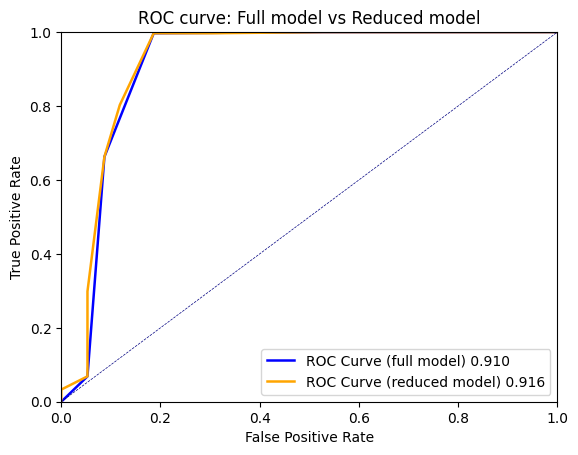

In [150]:
from sklearn.metrics import roc_auc_score, roc_curve
from matplotlib import pyplot as plt

y_pred_proba_lr_cv = cv.predict_proba(X_test_scaled)
y_pred_proba_cv_sel_model = cv_sel_model.predict_proba(X_test_sel_model)

roc_index_lr_cv = roc_auc_score(y_test, y_pred_proba_lr_cv[:, 1])
roc_index_cv_sel_model = roc_auc_score(y_test, y_pred_proba_cv_sel_model[:, 1])

print("ROC index on test for `cv`:", roc_index_lr_cv)
print("ROC index on test for `cv_sel_model`:", roc_index_cv_sel_model)

# ROC curve
fpr_lr_cv, tpr_lr_cv, thresholds_lr_cv = roc_curve(y_test, y_pred_proba_lr_cv[:, 1])
fpr_cv_sel_model, tpr_cv_sel_model, thresholds_cv_sel_model = roc_curve(
    y_test, y_pred_proba_cv_sel_model[:, 1]
)

plt.plot(
    fpr_lr_cv,
    tpr_lr_cv,
    label=f"ROC Curve (full model) {roc_index_lr_cv:.3f}",
    color="blue",
    lw=1.8,
)
plt.plot(
    fpr_cv_sel_model,
    tpr_cv_sel_model,
    label=f"ROC Curve (reduced model) {roc_index_cv_sel_model:.3f}",
    color="orange",
    lw=1.8,
)

plt.plot([0, 1], [0, 1], color="navy", lw=0.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve: Full model vs Reduced model")
plt.legend(loc="lower right")
plt.show()

**Response:**  
The AUC score of the full model (50 variables) is 0.91, while the reduced model (2 variables) achieves a slightly higher AUC of 0.916. Both models demonstrate strong predictive performance according to the ROC curve. Although the improvement of 0.006 is marginal, the reduced model outperforms the full model while using significantly fewer variables. This suggests that the selected features are sufficient to capture the underlying patterns in the data, resulting in a more efficient and simpler model with comparable (or slightly better) generalisation performance.